### DATA PREPROCESSING AND FEATURE SELECTION

#### 1.DATA PREPROCESSING 
CONVERTING CATEGORICAL COLUMNS TO NUMERICAL 

CHECKING AND IMPUTING NULL VALUES

CHECKING AND HANDLING OUTLIERS

FEATURE TRANSFORMATION

#### 2.FEATURE ENGENEERING
FEATURE SELECTION

FEATURE CREATION

USING HEATMAP AND DROPPING HIGHLY CORRRLATED FEATURES

DROP CONSTANT COLUMNS

DROP DUPLICATES

PRINCIPAL COMPONENET ANALYSIS

SAVE PREPROCESSED DATA

#### IMPORTING CORE LIBRARIES

In [1]:
# importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# importing preprocessing 
from sklearn.preprocessing import StandardScaler ,OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA

In [2]:
## loading data
data = pd.read_excel(r"C:\Users\DELL\Downloads\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8 (1).xls")

In [3]:
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


#### CHECKING NULL VALUES

In [4]:
data.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

##### The dataset does not contain any missing/null values

#### CONVERTING CATEGORICAL TO NUMERICAL

In [5]:
# Select categorical columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns

# Print them one by one
for col in cat_cols:
    print(f"The categorical column: {col}")


The categorical column: EmpNumber
The categorical column: Gender
The categorical column: EducationBackground
The categorical column: MaritalStatus
The categorical column: EmpDepartment
The categorical column: EmpJobRole
The categorical column: BusinessTravelFrequency
The categorical column: OverTime
The categorical column: Attrition


#### TECHNIQUES USED
##### LABEL ENCODER :
A Label Encoder is a preprocessing tool in machine learning that converts categorical values (like text labels) into numeric codes. it works by assigning unique integer to categorical labels.
##### MANUAL ENCODING :
Manual encoding is a custom mapping of categories to numeric codes based on logic, domain knowledge, or ordering.
##### FREQUENCY ENCODING:
Frequency Encoding is a categorical encoding technique where each category is replaced by the frequency (count or proportion) of that category in the dataset.



#### 1.GENDER 

In [6]:
data['Gender'].value_counts()

Gender
Male      725
Female    475
Name: count, dtype: int64

In [7]:
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})

In [8]:
# checking if it is converted
data['Gender'].value_counts()

Gender
1    725
0    475
Name: count, dtype: int64

#### 2.EDUCATION BACKGROUND

In [9]:
data['EducationBackground'].value_counts()

EducationBackground
Life Sciences       492
Medical             384
Marketing           137
Technical Degree    100
Other                66
Human Resources      21
Name: count, dtype: int64

In [10]:
data['EducationBackground']=data['EducationBackground'].map({'Human Resources':0,'Other':1,'Technical Degree':2,'Marketing':3,
                                                          'Medical':4, 'Life Sciences':5 })

In [11]:
data['EducationBackground'].value_counts()

EducationBackground
5    492
4    384
3    137
2    100
1     66
0     21
Name: count, dtype: int64

#### 3.MARITAL STATUS

In [12]:
data['MaritalStatus'].value_counts()

MaritalStatus
Married     548
Single      384
Divorced    268
Name: count, dtype: int64

In [13]:
data['MaritalStatus'] =data['MaritalStatus'].map({'Divorced':0,'Single':1,'Married':2})

In [14]:
data['MaritalStatus'].value_counts()

MaritalStatus
2    548
1    384
0    268
Name: count, dtype: int64

#### 4.EMP DEPARTMENT

In [15]:
data['EmpDepartment'].value_counts()

EmpDepartment
Sales                     373
Development               361
Research & Development    343
Human Resources            54
Finance                    49
Data Science               20
Name: count, dtype: int64

In [16]:
data.loc[data['EmpDepartment']=='Sales','EmpDepartment']=5
data.loc[data['EmpDepartment']=='Development','EmpDepartment']=4
data.loc[data['EmpDepartment']=='Research & Development','EmpDepartment']=3
data.loc[data['EmpDepartment']=='Human Resources','EmpDepartment']=2
data.loc[data['EmpDepartment']=='Finance','EmpDepartment']=1
data.loc[data['EmpDepartment']=='Data Science','EmpDepartment']=0

In [17]:
data['EmpDepartment'].value_counts()

EmpDepartment
5    373
4    361
3    343
2     54
1     49
0     20
Name: count, dtype: int64

#### 5.EMP JObROLe

In [18]:
data['EmpJobRole'].value_counts()

EmpJobRole
Sales Executive              270
Developer                    236
Manager R&D                   94
Research Scientist            77
Sales Representative          69
Laboratory Technician         64
Senior Developer              52
Manager                       51
Finance Manager               49
Human Resources               45
Technical Lead                38
Manufacturing Director        33
Healthcare Representative     33
Data Scientist                20
Research Director             19
Business Analyst              16
Senior Manager R&D            15
Delivery Manager              12
Technical Architect            7
Name: count, dtype: int64

In [19]:
# Use frequency encoding because feature contain a lots of label
data.loc[data['EmpJobRole']=='Sales Executive','EmpJobRole']=18
data.loc[data['EmpJobRole']=='Developer','EmpJobRole']=17
data.loc[data['EmpJobRole']=='Manager R&D','EmpJobRole']=16
data.loc[data['EmpJobRole']=='Research Scientist','EmpJobRole']=15
data.loc[data['EmpJobRole']=='Sales Representative','EmpJobRole']=14
data.loc[data['EmpJobRole']=='Laboratory Technician','EmpJobRole']=13
data.loc[data['EmpJobRole']=='Senior Developer','EmpJobRole']=12
data.loc[data['EmpJobRole']=='Manager','EmpJobRole']=11
data.loc[data['EmpJobRole']=='Finance Manager','EmpJobRole']=10
data.loc[data['EmpJobRole']=='Human Resources','EmpJobRole']=9
data.loc[data['EmpJobRole']=='Technical Lead','EmpJobRole']=8
data.loc[data['EmpJobRole']=='Manufacturing Director','EmpJobRole']=7
data.loc[data['EmpJobRole']=='Healthcare Representative','EmpJobRole']=6
data.loc[data['EmpJobRole']=='Data Scientist','EmpJobRole']=5
data.loc[data['EmpJobRole']=='Research Director','EmpJobRole']=4
data.loc[data['EmpJobRole']=='Business Analyst','EmpJobRole']=3
data.loc[data['EmpJobRole']=='Senior Manager R&D','EmpJobRole']=2
data.loc[data['EmpJobRole']=='Delivery Manager','EmpJobRole']=1
data.loc[data['EmpJobRole']=='Technical Architect','EmpJobRole']=0

In [20]:
data['EmpJobRole'].value_counts()

EmpJobRole
18    270
17    236
16     94
15     77
14     69
13     64
12     52
11     51
10     49
9      45
8      38
7      33
6      33
5      20
4      19
3      16
2      15
1      12
0       7
Name: count, dtype: int64

#### 6.OverTime

In [21]:
le = LabelEncoder()
data['OverTime']=le.fit_transform(data['OverTime'])

#### 7.BusinessTravelFrequency

In [22]:
data['BusinessTravelFrequency']=le.fit_transform(data['BusinessTravelFrequency'])

#### 8.Attrition

In [23]:
data.Attrition.value_counts()

Attrition
No     1022
Yes     178
Name: count, dtype: int64

In [24]:
data['Attrition'] = data['Attrition'].map({'Yes':0, 'No':1})

In [25]:
data['Attrition'].value_counts()

Attrition
1    1022
0     178
Name: count, dtype: int64

#### 9.EmpNumber

In [26]:
#dropping EMp number as it has unique values and do not contirbute to identify any patterns,relationship with target variable
data.drop(['EmpNumber'],axis=1,inplace=True)

In [28]:
### checking data set
data.tail(3)

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
1197,50,1,4,2,4,12,2,28,1,4,...,3,20,3,3,20,8,3,8,1,3
1198,34,0,4,1,0,5,2,9,3,4,...,2,9,3,4,8,7,7,7,1,3
1199,24,0,5,1,5,18,2,3,2,1,...,1,4,3,3,2,2,2,0,0,2


### CHECKING AND HANDLING OUTLIERS

PLOT USED : BOX PLOT
A box plot is a statistical visualization that shows the distribution of a numeric variable using its five‑number summary: minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum. It highlights spread, central tendency, and outliers in a compact way. 

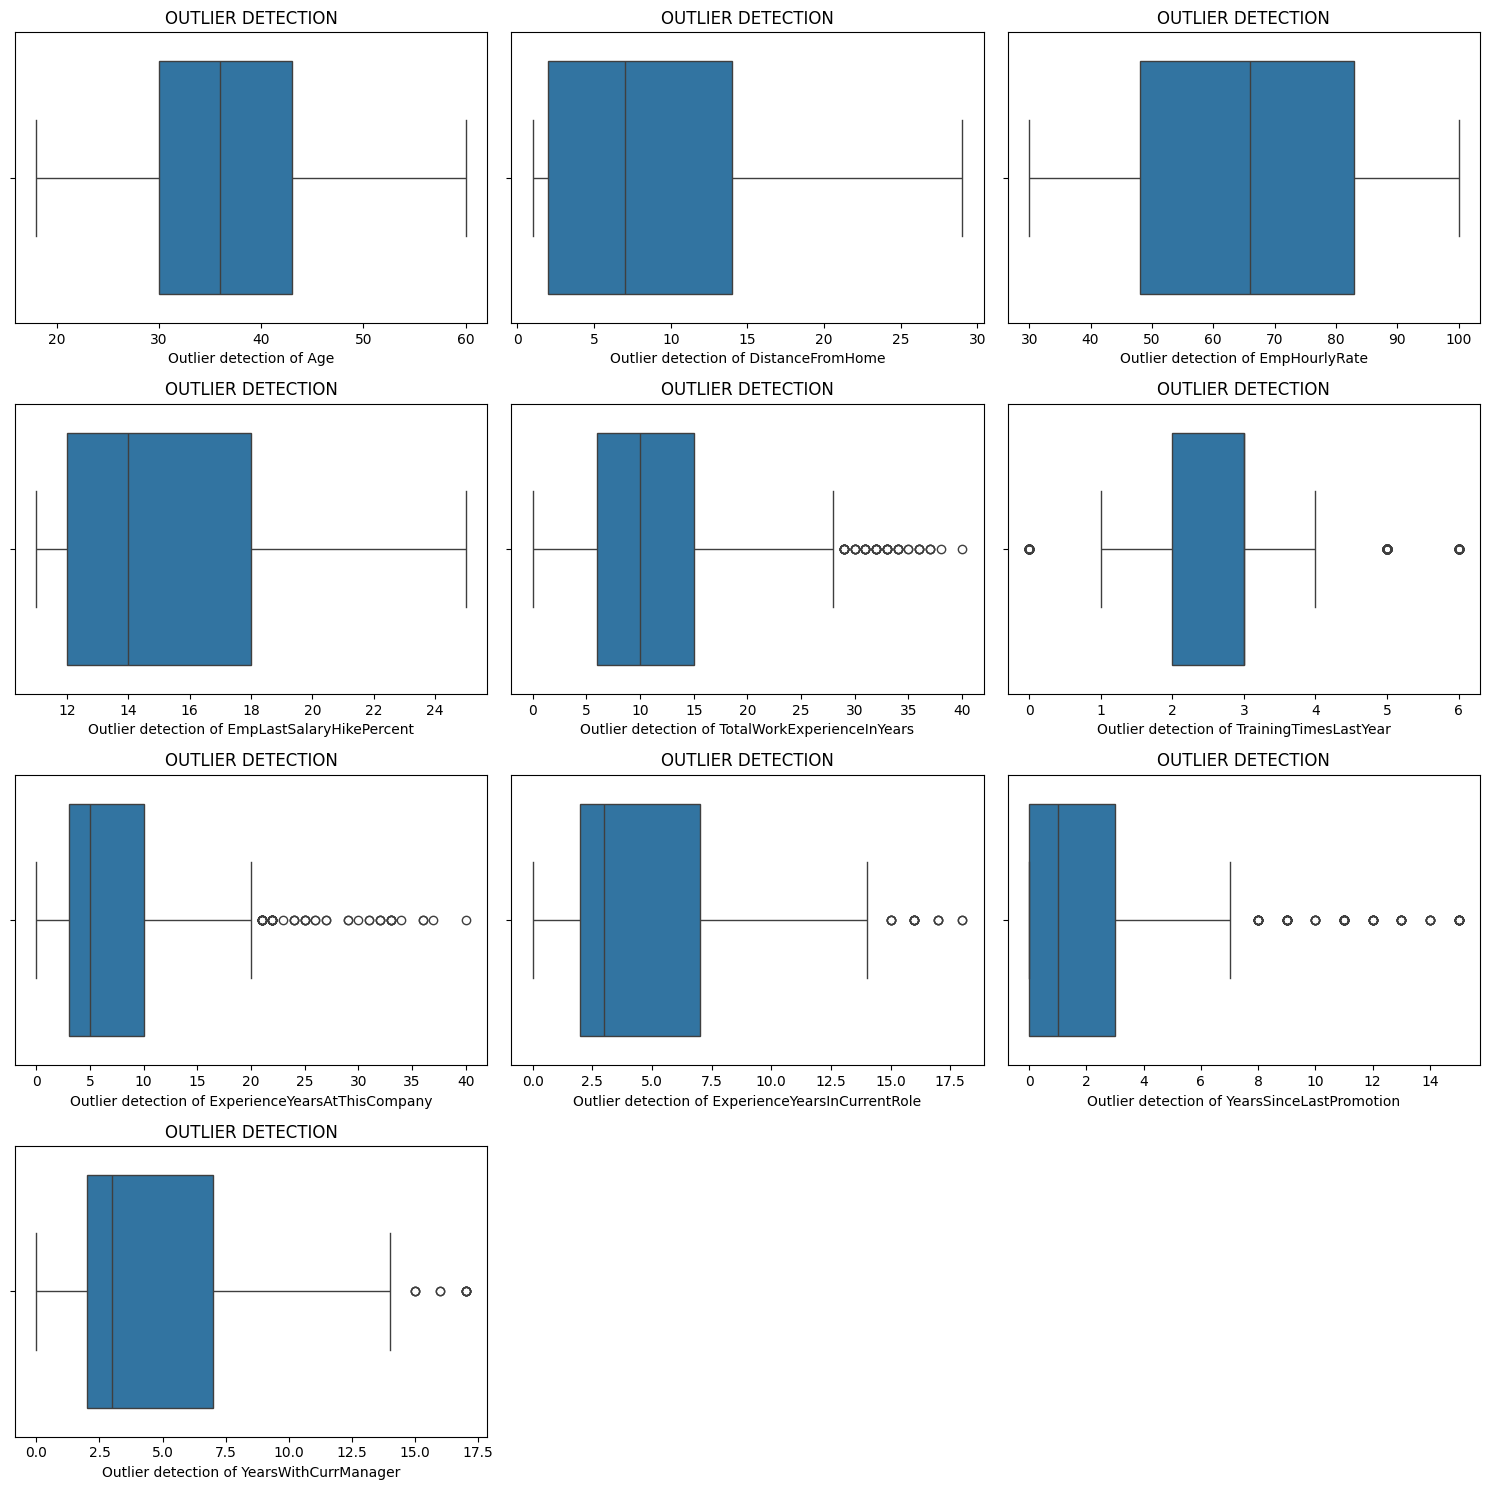

In [29]:
cols = ['Age','DistanceFromHome','EmpHourlyRate','EmpLastSalaryHikePercent',
                   'TotalWorkExperienceInYears','TrainingTimesLastYear','ExperienceYearsAtThisCompany',
                   'ExperienceYearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
plt.figure(figsize=(15,15))
for idx, col in enumerate(cols,1):
    plt.subplot(4,3,idx)
    sns.boxplot(x=data[col],data=data)
    plt.title('OUTLIER DETECTION')
    plt.xlabel(f"Outlier detection of {col}")
plt.tight_layout()
plt.show()

### HANDLING OUTLIERS
TECHNIQUES USED : Using IQR method to impute outliers

In [30]:
from scipy import stats

# Columns you want to process
cols = [
    'TotalWorkExperienceInYears',
    'TrainingTimesLastYear',
    'ExperienceYearsAtThisCompany',
    'ExperienceYearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

# Iterate through each column
for col in cols:
    # Calculate IQR
    iqr = stats.iqr(data[col], interpolation='midpoint')
    print(f"IQR for {col}:", iqr)

    # Get first and third quantile
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    # Get minimum and maximum limit
    min_limit = Q1 - 1.5 * iqr
    max_limit = Q3 + 1.5 * iqr
    print(f"{col} → Min limit: {min_limit}, Max limit: {max_limit}")

    # Impute outliers with median
    median = data[col].median()
    data.loc[data[col] < min_limit, col] = median
    data.loc[data[col] > max_limit, col] = median

  

IQR for TotalWorkExperienceInYears: 9.0
TotalWorkExperienceInYears → Min limit: -7.5, Max limit: 28.5
IQR for TrainingTimesLastYear: 1.0
TrainingTimesLastYear → Min limit: 0.5, Max limit: 4.5
IQR for ExperienceYearsAtThisCompany: 7.0
ExperienceYearsAtThisCompany → Min limit: -7.5, Max limit: 20.5
IQR for ExperienceYearsInCurrentRole: 5.0
ExperienceYearsInCurrentRole → Min limit: -5.5, Max limit: 14.5
IQR for YearsSinceLastPromotion: 3.0
YearsSinceLastPromotion → Min limit: -4.5, Max limit: 7.5
IQR for YearsWithCurrManager: 5.0
YearsWithCurrManager → Min limit: -5.5, Max limit: 14.5


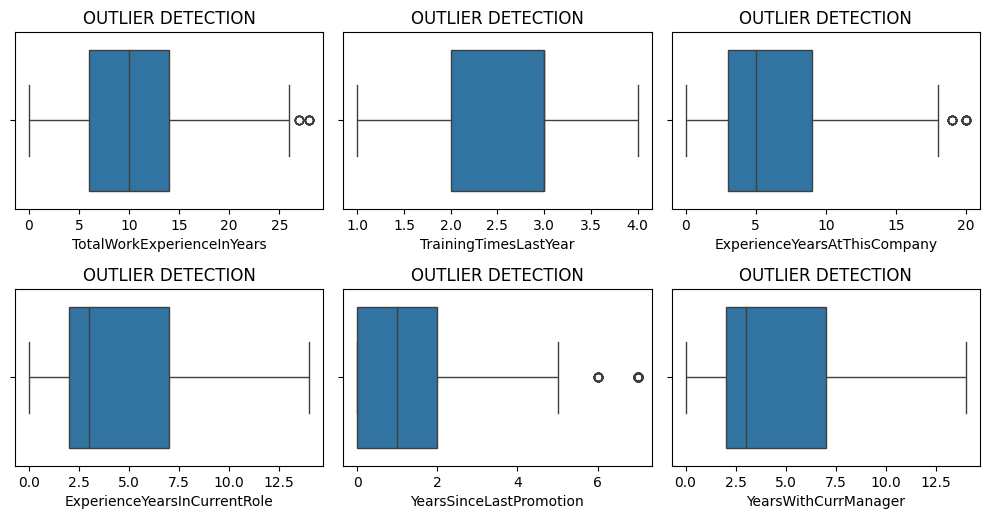

In [31]:
# checking if imputation is done
cols = ['TotalWorkExperienceInYears','TrainingTimesLastYear','ExperienceYearsAtThisCompany',
                   'ExperienceYearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
plt.figure(figsize=(10,10))
for idx, col in enumerate(cols,1):
    plt.subplot(4,3,idx)
    sns.boxplot(x=data[col],data=data)
    plt.title('OUTLIER DETECTION')
    plt.xlabel(f"{col}")
plt.tight_layout()
plt.show()

OBSERVATION:
Outlier impute sucessfully, but some feature box plot showing outlier, so we can not impute this outlier.

In [32]:
data['PerformanceRating'].value_counts()

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

### FEATURE TRANSFORMATION
from EDA we found that the feature yearssince last promotion is highly right skewed.. so we transforming using log transformation

<Axes: xlabel='YearsSinceLastPromotion', ylabel='Count'>

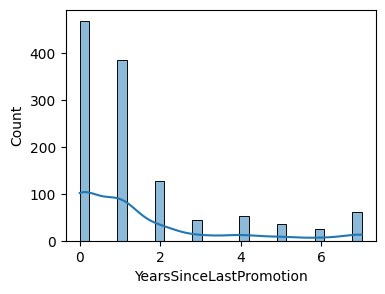

In [33]:
plt.figure(figsize=(4,3))
sns.histplot(x=data['YearsSinceLastPromotion'],kde=True,bins=30)

#### LOG TRANSFORMATION

In [34]:
import numpy as np
data['YearsSinceLastPromotion_log'] = np.log1p(data['YearsSinceLastPromotion'])

<Axes: xlabel='YearsSinceLastPromotion_log', ylabel='Count'>

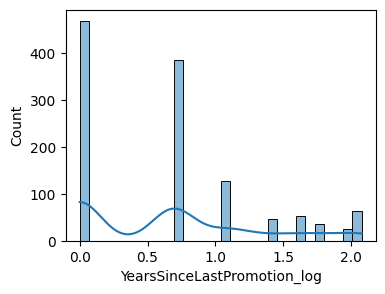

In [35]:
plt.figure(figsize=(4,3))
sns.histplot(x=data['YearsSinceLastPromotion_log'],kde=True,bins=30)

### SCALING THE DATA
#### STANDARD SCALAR : 
StandardScaler is a preprocessing tool in scikit‑learn that standardizes features by removing the mean and scaling them to unit variance, so each feature has mean = 0 and standard deviation = 1. 

In [38]:
# Columns to scale
cols_to_scale = [
    'Age','DistanceFromHome','EmpHourlyRate','EmpLastSalaryHikePercent',
    'TotalWorkExperienceInYears','TrainingTimesLastYear',
    'ExperienceYearsAtThisCompany','ExperienceYearsInCurrentRole',
    'YearsWithCurrManager','YearsSinceLastPromotion_log'
]

# Initialize scaler
scaler = StandardScaler()

# Fit and transform
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])



In [40]:
data.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating,YearsSinceLastPromotion_log
0,-0.541458,1,3,1,5,18,2,0.102061,3,4,...,-0.058535,-0.879579,2,0.868276,0.864098,0,1.202103,1,3,-1.012816
1,1.109888,1,3,1,5,18,2,0.591464,4,4,...,1.512870,-0.879579,3,0.200371,0.864098,1,0.902825,1,3,0.050319
2,0.339260,1,5,2,5,18,1,-0.509693,4,4,...,1.512870,-0.879579,3,2.649355,2.661702,1,2.399219,1,4,0.050319
3,0.449349,1,0,0,2,11,2,0.102061,4,2,...,1.984292,-0.879579,2,-0.244898,0.564498,1,0.603546,1,3,0.050319
4,2.541054,1,3,1,5,18,2,0.836165,4,1,...,-0.058535,-2.303999,3,-0.912803,-0.633905,2,-0.593570,1,3,0.672213


In [41]:
### dropping yearssincelastpromotion as we are using transformed value
data.drop(['YearsSinceLastPromotion'],axis=1,inplace=True)

### CORRELATION ANALYSIS USING HEAT MAP

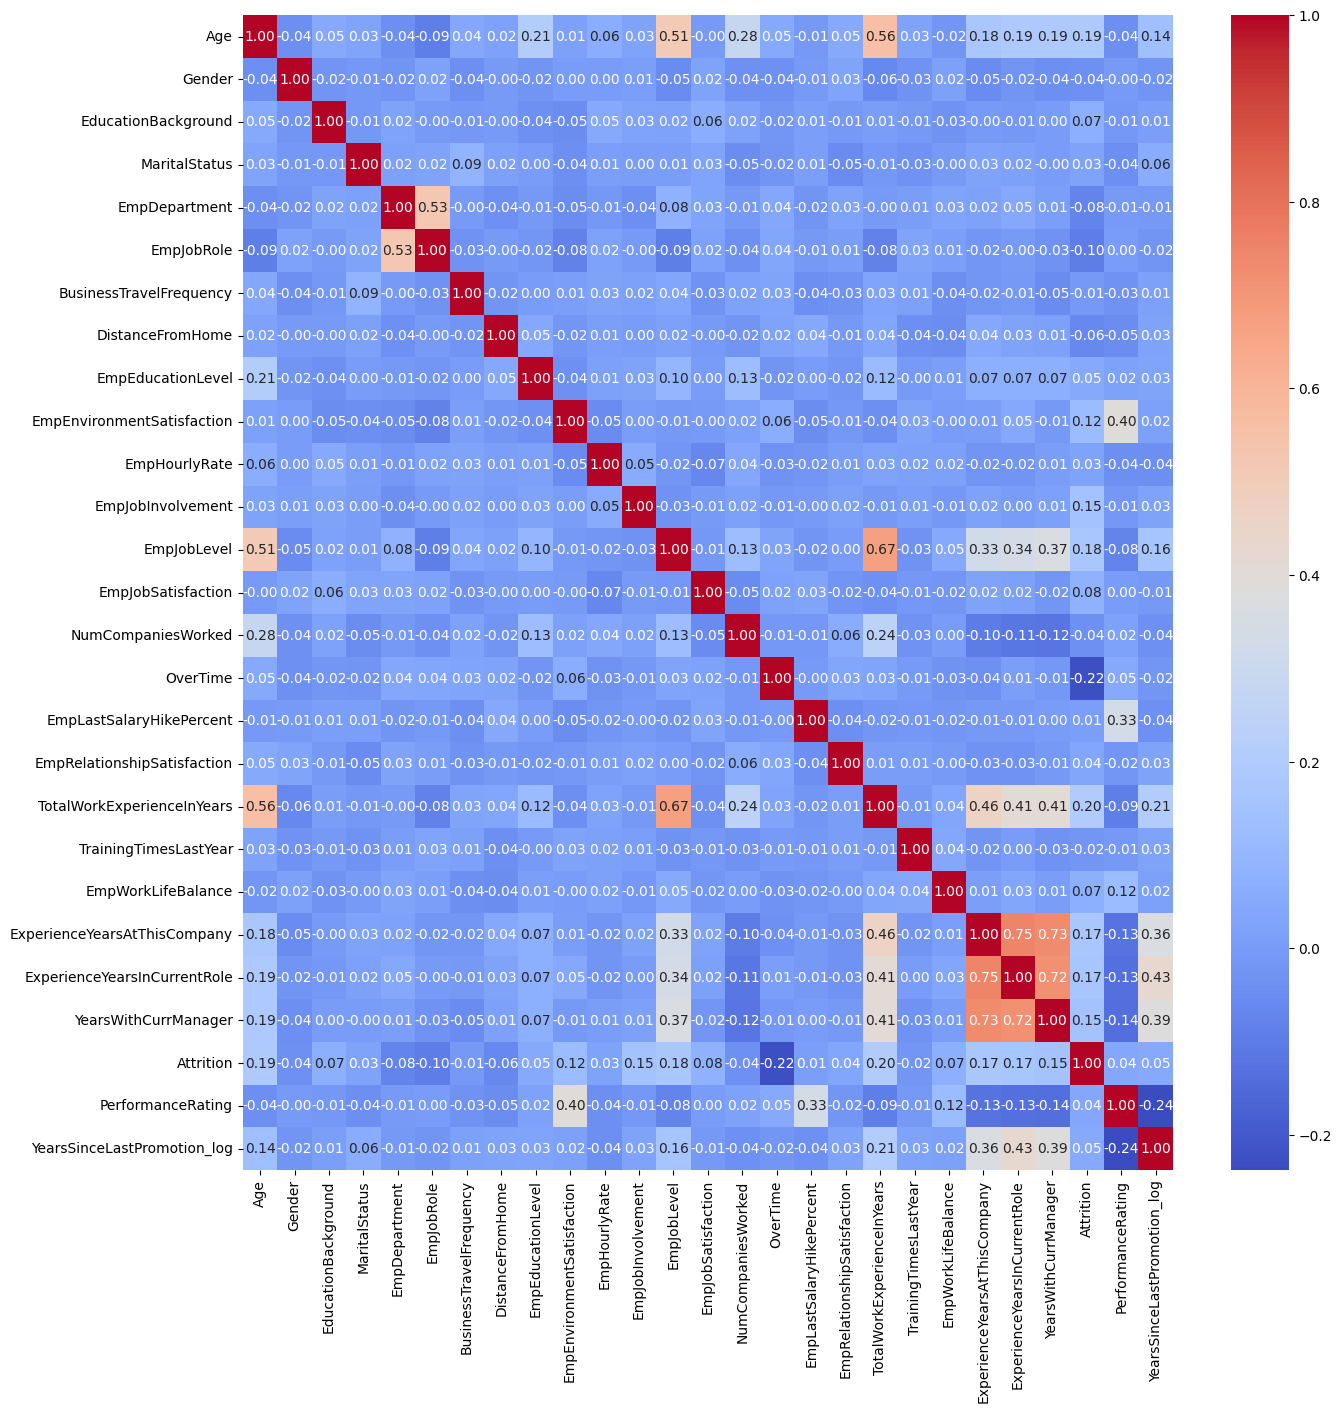

In [42]:
plt.figure(figsize=(15,15))
tc = data.corr()

sns.heatmap(
    tc,
    annot=True,       # show correlation values
    cmap='coolwarm',  # color scheme
    fmt=".2f"         # format numbers with 2 decimals
)

plt.show()


from heatmap we can see that there are no highly correlated features

#### CHECKING DUPLICATES

In [43]:
data.duplicated().sum()

np.int64(0)

there are no duplicates in data

### PRINCIPAL COMPONENT ANALYSIS

Principal Component Analysis (PCA) is a dimensionality reduction technique used in statistics and machine learning. It transforms a dataset with many correlated variables into a smaller set of uncorrelated variables called principal components, while preserving as much variance (information) as possible.

getting optimal value of pca

A Scree Plot is a line plot that shows the explained variance (or eigenvalues) of each principal component in PCA. It helps you decide how many components to keep by visualizing where the variance contribution drops off (the “elbow point”).

Number of components to retain (95% variance): 18


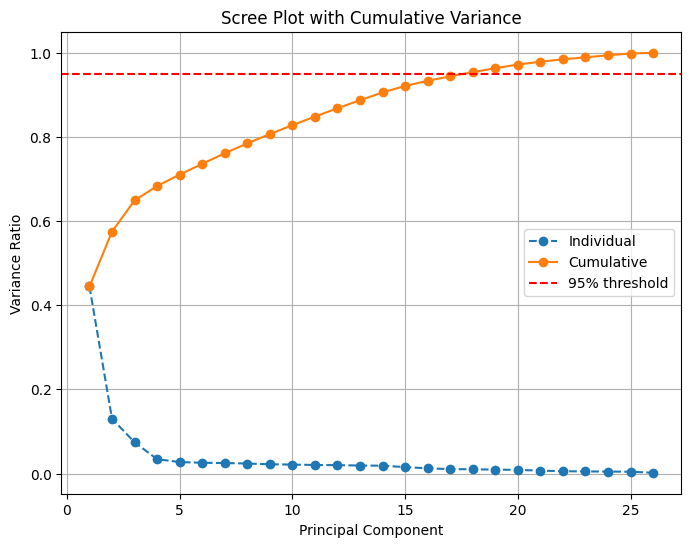

In [44]:
# The target variable must be excluded before performing PCA to avoid bias and data leakage, since PCA is an unsupervised technique applied only to independent variables.”
X = data.drop(['PerformanceRating'],axis=1)
# Fit PCA on your numeric dataset
pca = PCA()
pca.fit(X)  

# Explained variance ratios
explained_var = pca.explained_variance_ratio_

# Cumulative explained variance
cum_var = explained_var.cumsum()

# Find number of components needed for 95% variance
n_components_95 = (cum_var < 0.95).sum() + 1
print(f"Number of components to retain (95% variance): {n_components_95}")

# Plot scree + cumulative variance
plt.figure(figsize=(8,6))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='--', label='Individual')
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='-', label='Cumulative')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.title('Scree Plot with Cumulative Variance')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.legend()
plt.grid(True)
plt.show()


In [46]:
# Selecting the components
pca = PCA(n_components=18)
data_pca = pca.fit_transform(X)
data_pca

array([[ 4.47964305, -1.62704805,  1.07357425, ...,  0.67075957,
        -0.82587786, -0.1224921 ],
       [ 4.35659621, -0.06614532,  2.00036572, ...,  0.1950209 ,
        -0.54172157,  0.3053741 ],
       [ 4.24356377,  2.56013892,  4.407639  , ...,  1.32436302,
         0.69271919, -0.43364416],
       ...,
       [-1.6429739 , -1.7320661 ,  3.16214556, ...,  1.15146885,
        -1.43150538,  0.97841651],
       [-9.10630864, -2.09729475,  1.49560988, ..., -0.75636317,
         1.82855147, -0.01143686],
       [ 4.36422652,  5.98551112, -2.16477439, ..., -0.64451229,
         0.36168509,  0.37533175]], shape=(1200, 18))

In [47]:
data_pca

array([[ 4.47964305, -1.62704805,  1.07357425, ...,  0.67075957,
        -0.82587786, -0.1224921 ],
       [ 4.35659621, -0.06614532,  2.00036572, ...,  0.1950209 ,
        -0.54172157,  0.3053741 ],
       [ 4.24356377,  2.56013892,  4.407639  , ...,  1.32436302,
         0.69271919, -0.43364416],
       ...,
       [-1.6429739 , -1.7320661 ,  3.16214556, ...,  1.15146885,
        -1.43150538,  0.97841651],
       [-9.10630864, -2.09729475,  1.49560988, ..., -0.75636317,
         1.82855147, -0.01143686],
       [ 4.36422652,  5.98551112, -2.16477439, ..., -0.64451229,
         0.36168509,  0.37533175]], shape=(1200, 18))

#### CREATE NEW DATAFRAME

In [49]:
pca_df = pd.DataFrame(data=data_pca,columns=['pca1','pca2','pca3','pca4','pca5','pca6','pca7','pca8','pca9','pca10',
                            'pca11','pca12','pca13','pca14','pca15','pca16','pca17','pca18'])

# Add target veriable to preprocess dataframe for model building & evaluation
pca_df['PerformanceRating']=data.PerformanceRating

pca_df.head()


,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,PerformanceRating
0,4.479643,-1.627048,1.073574,-0.923963,-0.847024,0.599013,1.606343,1.047469,0.426828,-0.821041,-1.034051,0.700567,-0.562173,0.279809,-1.360177,0.670760,-0.825878,-0.122492,3
1,4.356596,-0.066145,2.000366,-1.502314,0.512062,-1.380976,1.073136,-0.081239,0.861528,-1.442057,-1.623616,-0.868818,0.031611,-0.271569,-0.214222,0.195021,-0.541722,0.305374,3
2,4.243564,2.560139,4.407639,0.241121,-1.602938,-0.728390,-0.476236,-0.714438,-0.207199,-1.466593,-0.525027,-1.918682,-2.010848,-0.037737,-0.948503,1.324363,0.692719,-0.433644,4
3,-3.013216,0.728426,2.304887,-3.287041,2.385002,2.166544,-0.077489,0.086564,-0.027529,0.028998,0.305611,1.448886,0.015107,-1.161032,-0.553581,-1.515116,0.314498,-0.857174,3
4,4.246381,5.966910,-0.254782,-0.815638,1.908906,-1.162024,-1.481351,1.264351,0.320094,-1.309962,-1.540866,0.526878,-0.316836,0.051807,1.565568,-0.692025,-0.752437,0.140602,3


In [51]:
# Save PCA reduced dataset to CSV
pca_df.to_csv('employee_performance_analysis_preprocessed_data.csv', index=False)

# Read the new preprocessed CSV file
df = pd.read_csv('employee_performance_analysis_preprocessed_data.csv')

# Get first five rows
print(df.head())


       pca1      pca2      pca3      pca4      pca5      pca6      pca7  \
0  4.479643 -1.627048  1.073574 -0.923963 -0.847024  0.599013  1.606343   
1  4.356596 -0.066145  2.000366 -1.502314  0.512062 -1.380976  1.073136   
2  4.243564  2.560139  4.407639  0.241121 -1.602938 -0.728390 -0.476236   
3 -3.013216  0.728426  2.304887 -3.287041  2.385002  2.166544 -0.077489   
4  4.246381  5.966910 -0.254782 -0.815638  1.908906 -1.162024 -1.481351   

       pca8      pca9     pca10     pca11     pca12     pca13     pca14  \
0  1.047469  0.426828 -0.821041 -1.034051  0.700567 -0.562173  0.279809   
1 -0.081239  0.861528 -1.442057 -1.623616 -0.868818  0.031611 -0.271569   
2 -0.714438 -0.207199 -1.466593 -0.525027 -1.918682 -2.010848 -0.037737   
3  0.086564 -0.027529  0.028998  0.305611  1.448886  0.015107 -1.161032   
4  1.264351  0.320094 -1.309962 -1.540866  0.526878 -0.316836  0.051807   

      pca15     pca16     pca17     pca18  PerformanceRating  
0 -1.360177  0.670760 -0.825878 -0.